In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
from universe import candidates, correlation, pca
from evaluation import plot

returns, tickers = candidates.load_data()
loadings, p_comp = pca.fit_pca(returns, tickers)
matrix = correlation.corr_matrix(returns)

[*********************100%***********************]  23 of 23 completed


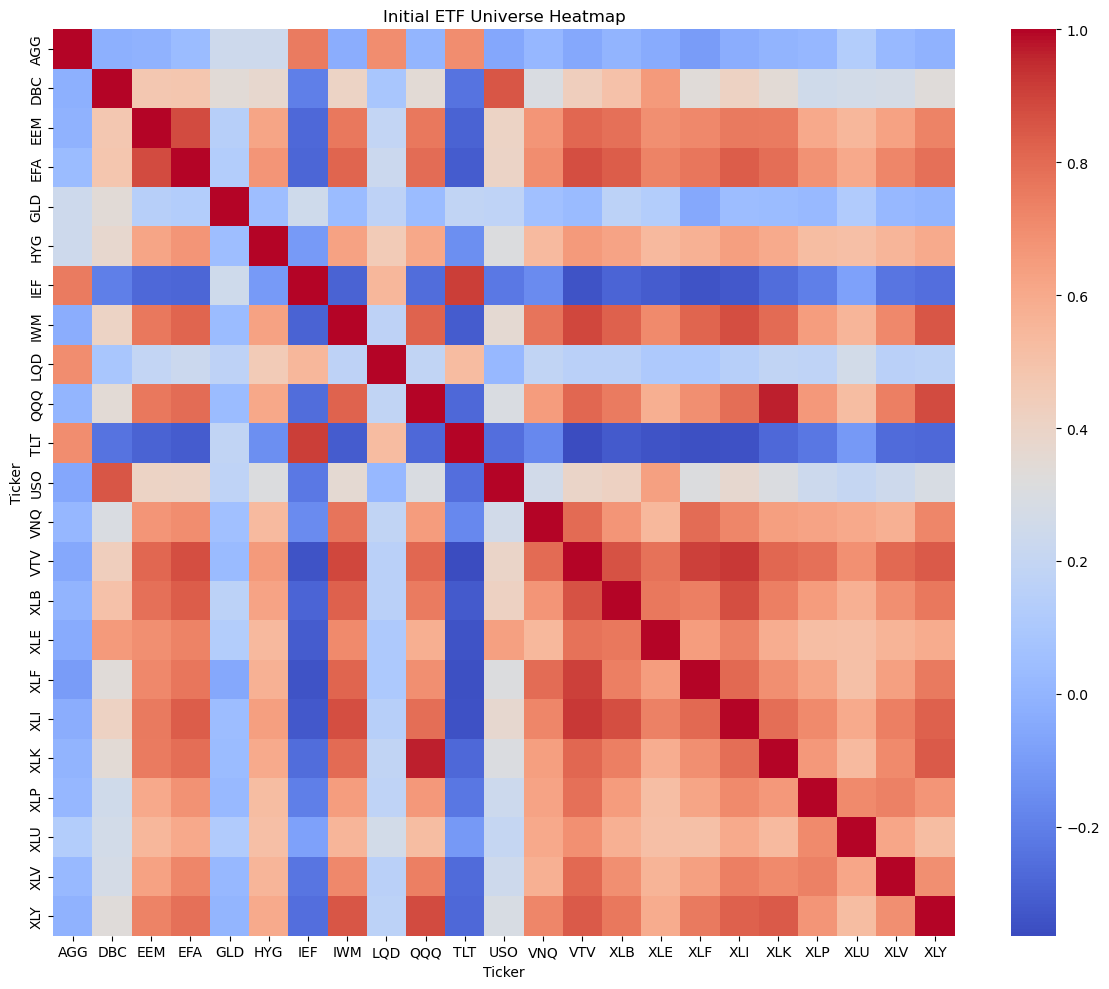

In [12]:
import matplotlib.pyplot as plt
import os

heatmap = plot.plot_correlation_heatmap(matrix)
os.makedirs('results/universe_selection', exist_ok = True)
heatmap.savefig('results/universe_selection/correlation_heatmap.png')

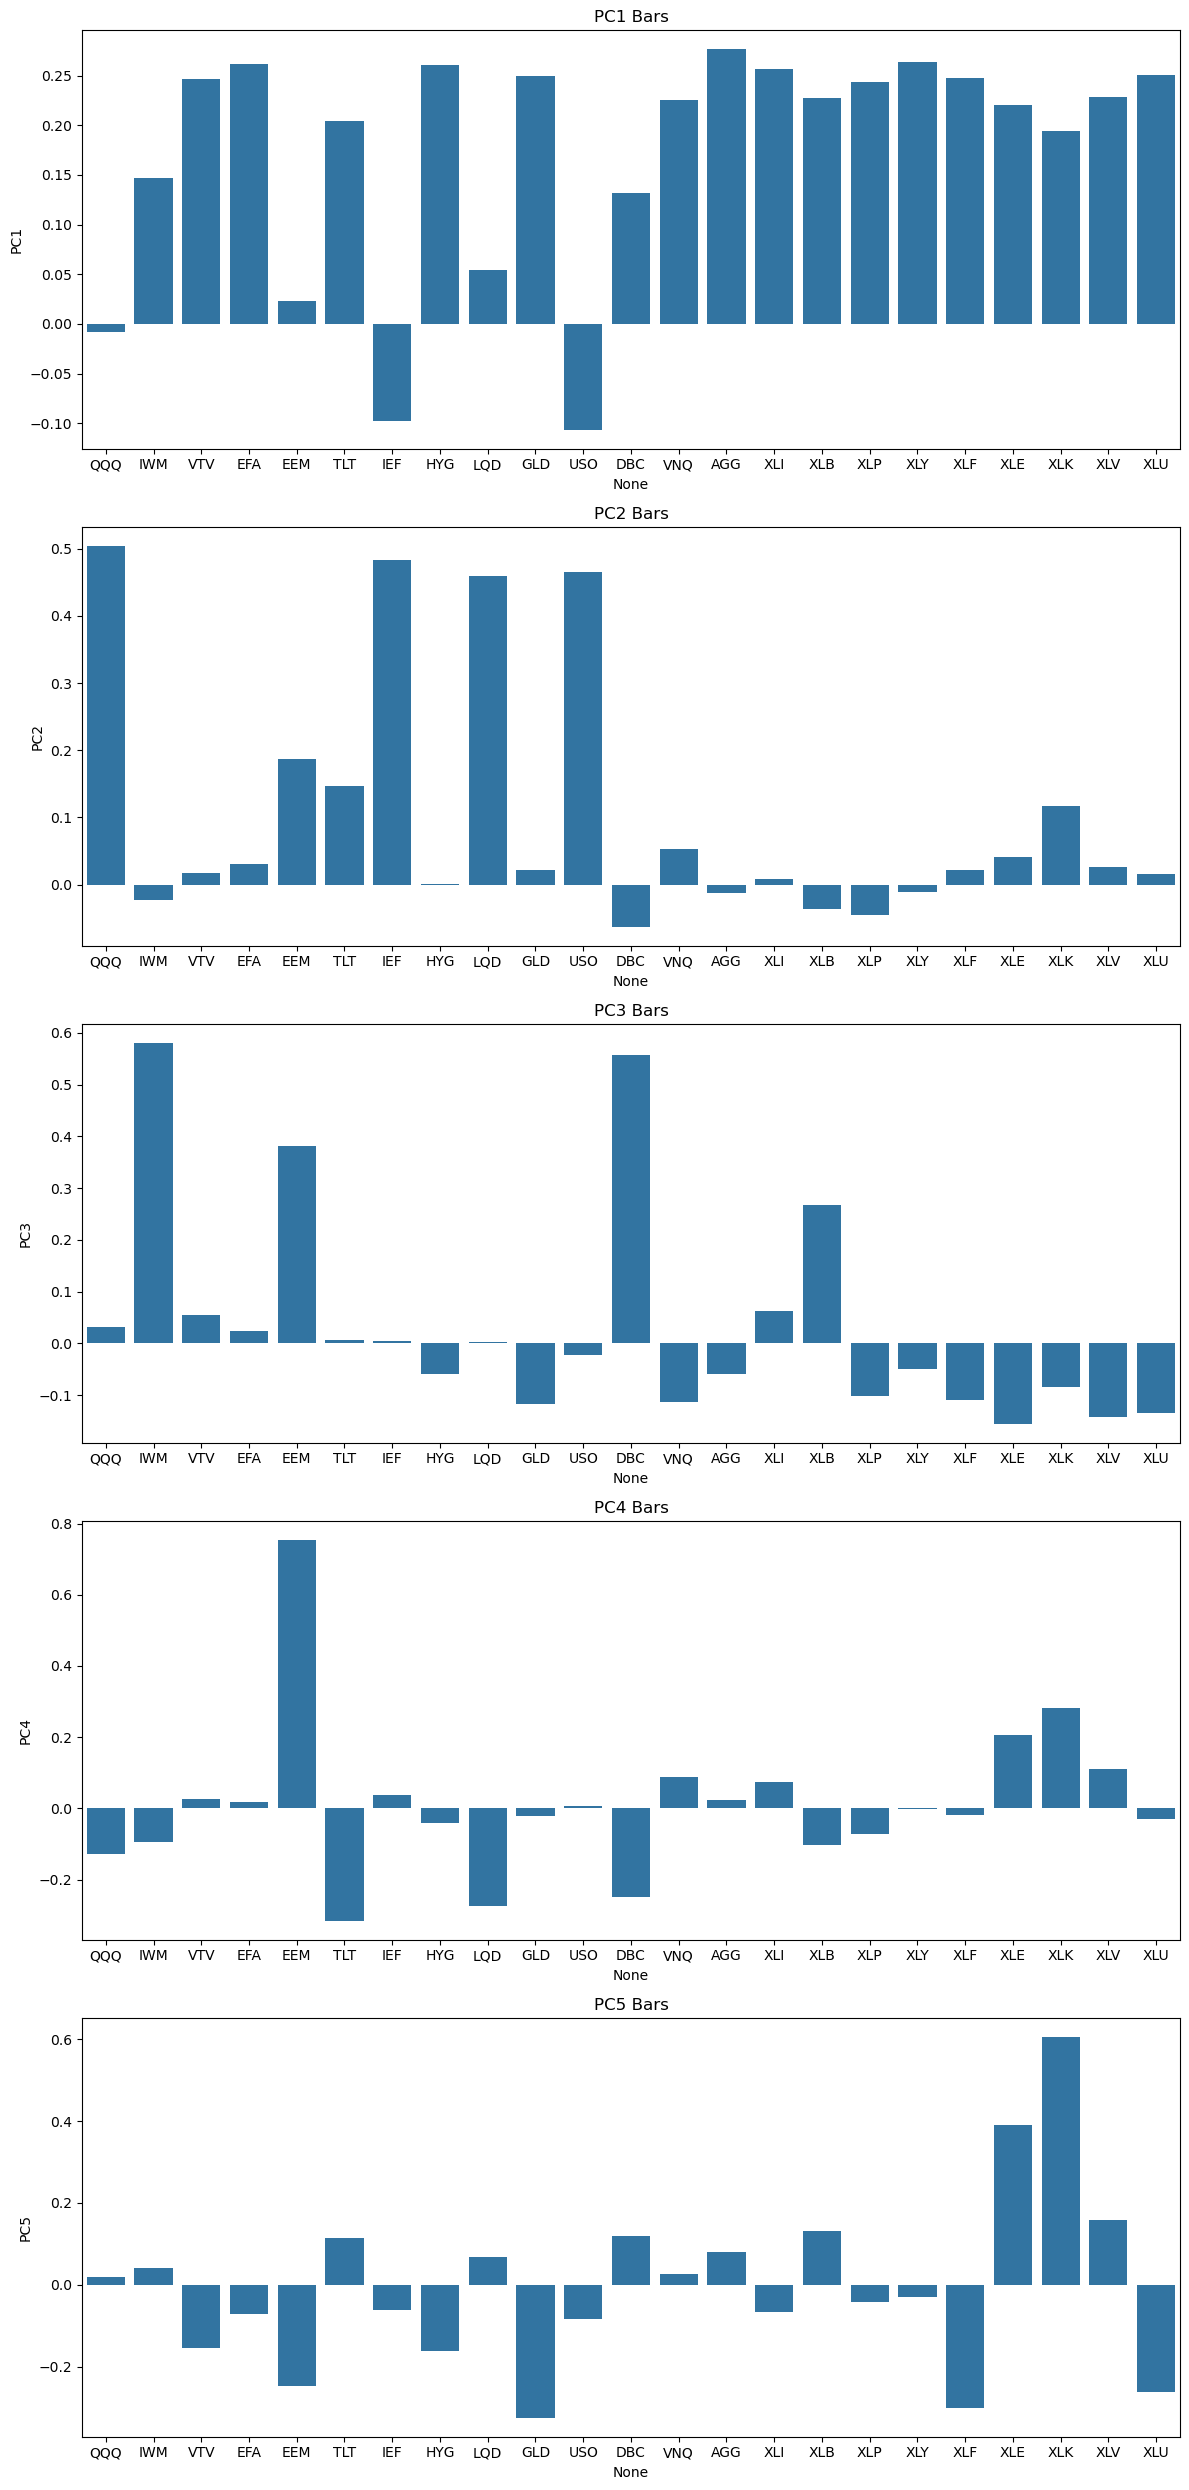

In [13]:
n_comp = pca.significant_components(p_comp)

pca_bars = plot.plot_pca_bars(loadings, n_comp)
os.makedirs('results/universe_selection', exist_ok = True)
pca_bars.savefig('results/universe_selection/pca_bars.png')

In [14]:
import pandas as pd

top_pcas = pca.top_pcas(loadings, n_comp)
top_pcas = correlation.correlation_check(top_pcas, matrix, loadings)
top_pcas = pd.DataFrame(top_pcas)
top_pcas.to_csv('results/universe_selection/final_assets.csv', index = False)